Ukuran dataset: (2576, 2000)
Jumlah window: 2576
Panjang setiap window: 2000 samples
Label unik: ['MI' 'Normal']

Contoh 5 window pertama (5 sample pertama):
[[-0.01555221  0.01696344  0.013575    0.02720385  0.0681543 ]
 [ 0.00232258  0.00275399  0.02253864  0.22880693  0.10775135]
 [ 0.05048134 -0.33978066  0.26511089  0.04509174  0.04008643]
 [ 0.02388189  0.01656122  0.24854723  0.05456748  0.12803238]
 [-0.05859058  0.17155111  0.05726166  0.27086884  0.13835707]]
Menerapkan MA-5 ke seluruh dataset...
Dataset setelah MA-5: (2576, 2000)


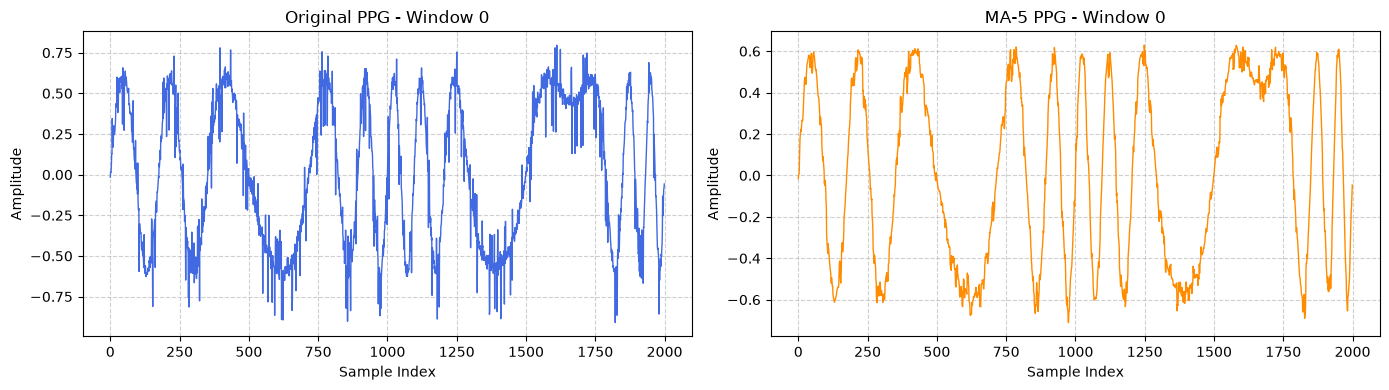

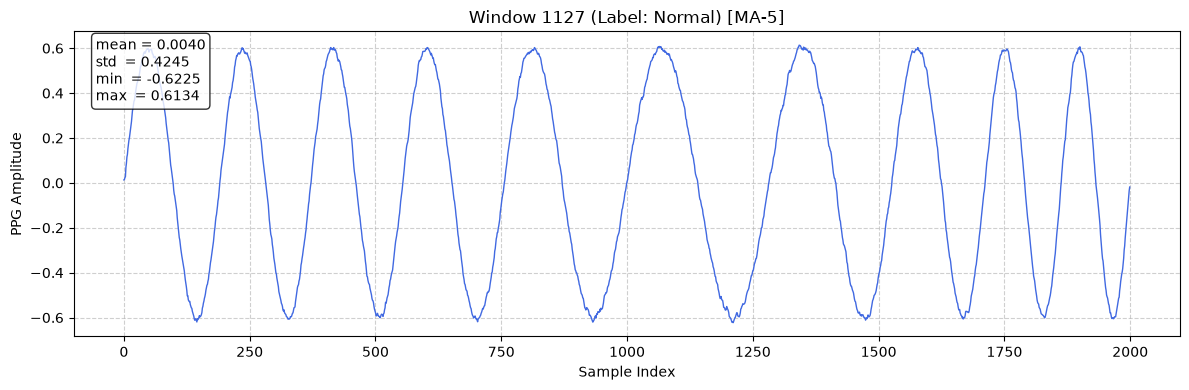

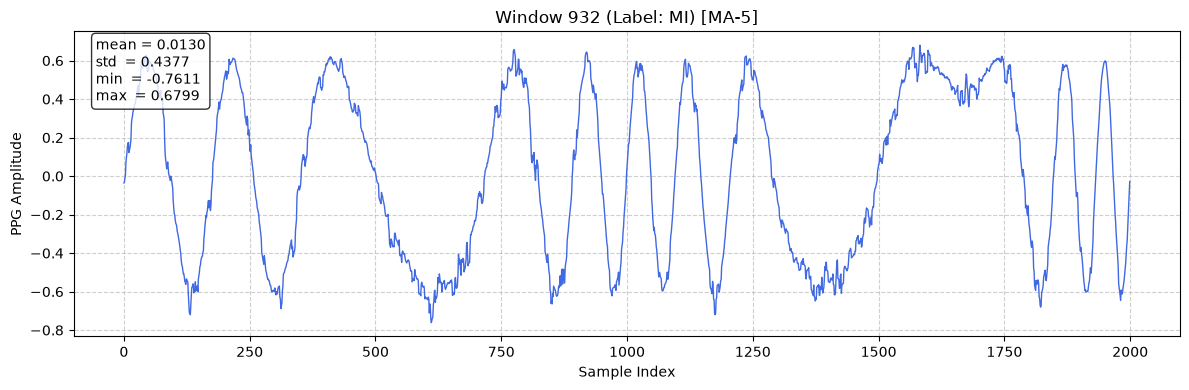

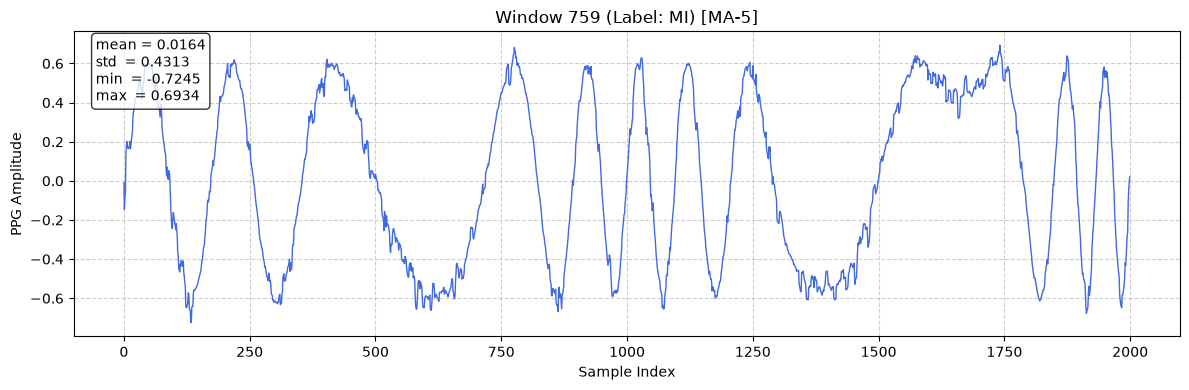

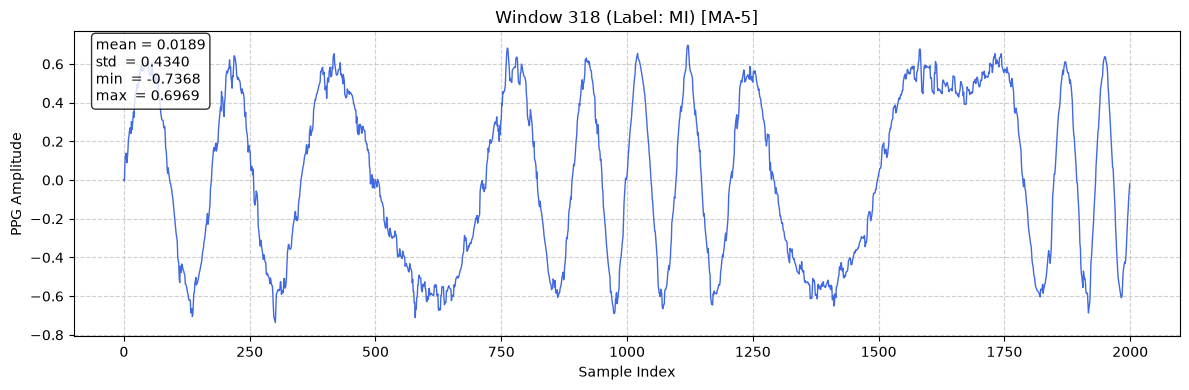

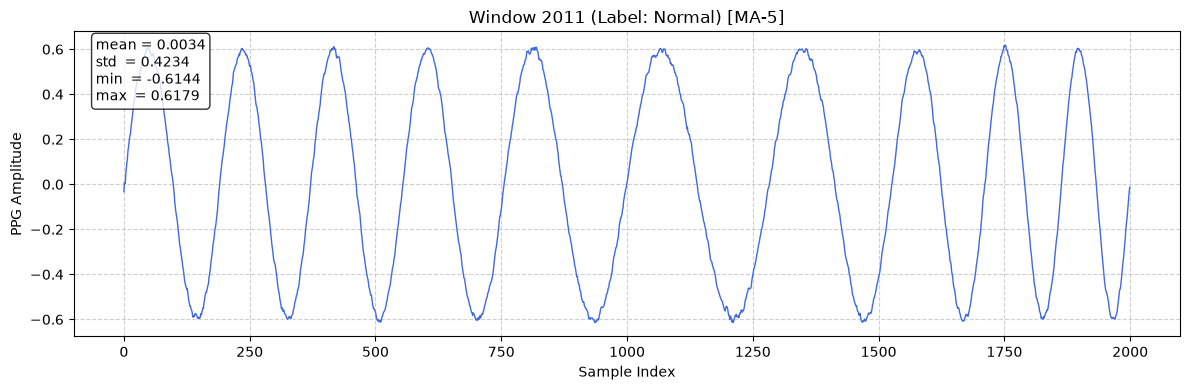

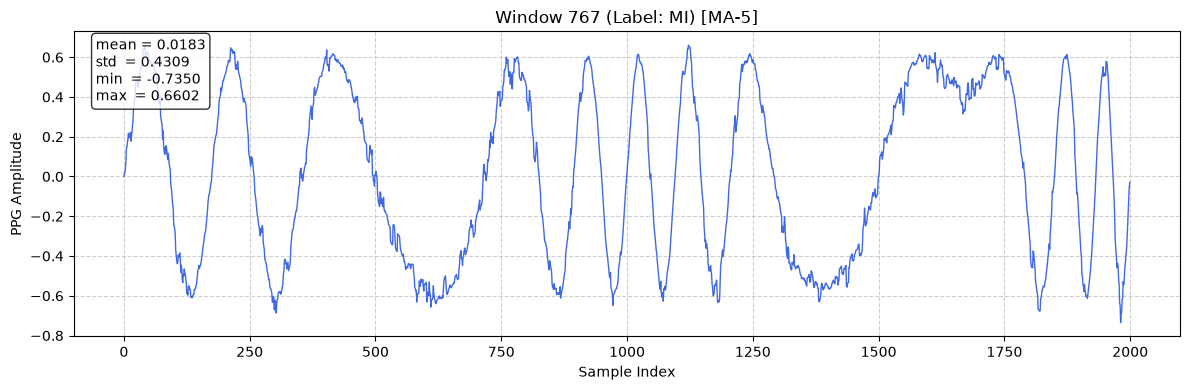

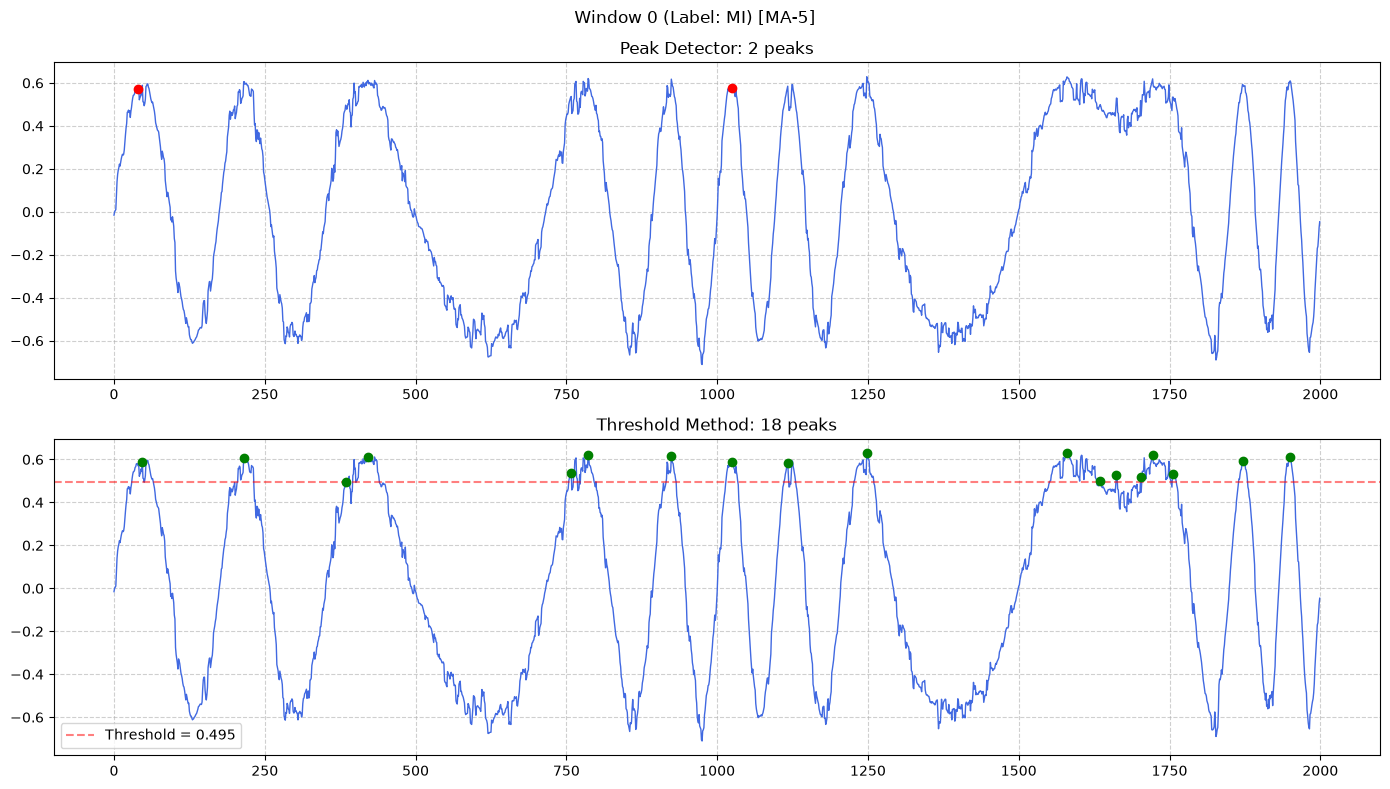

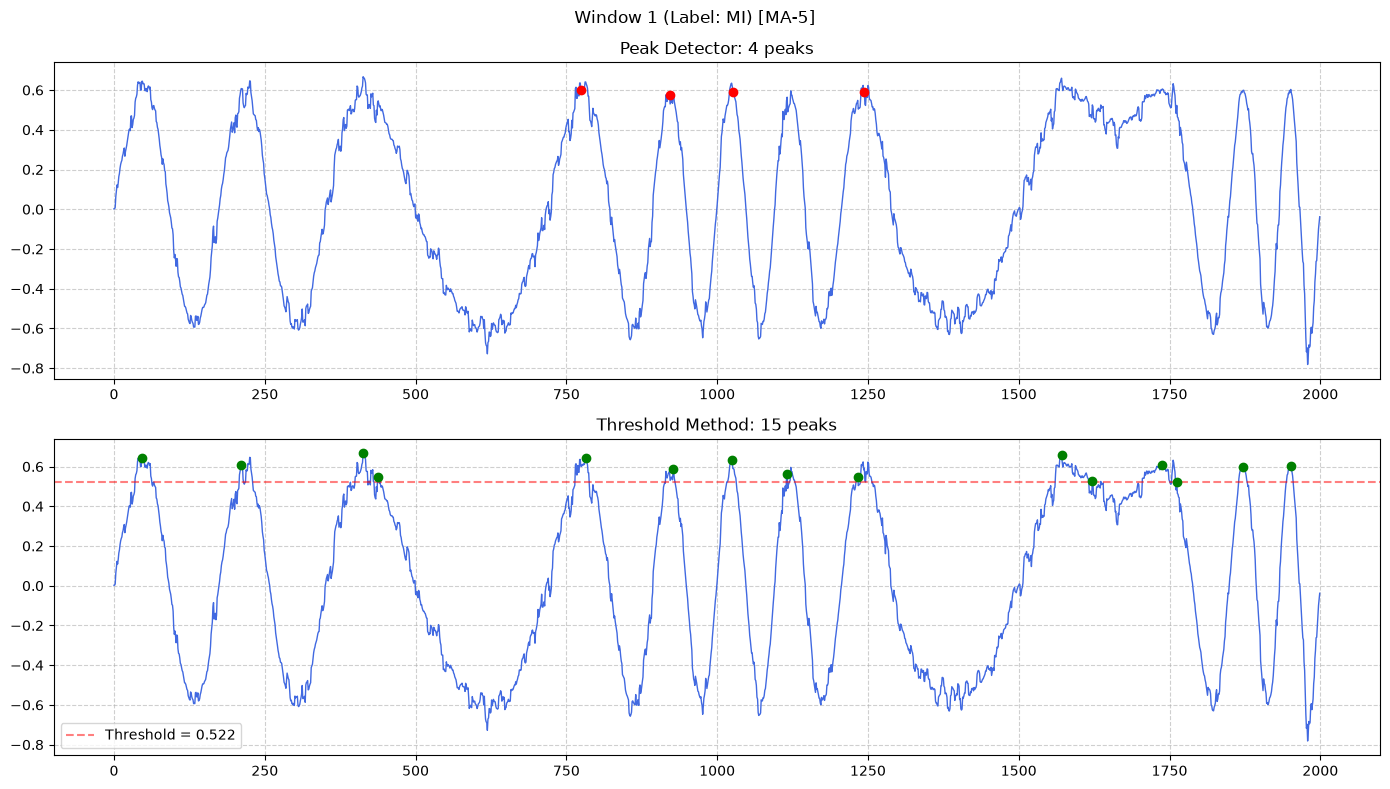

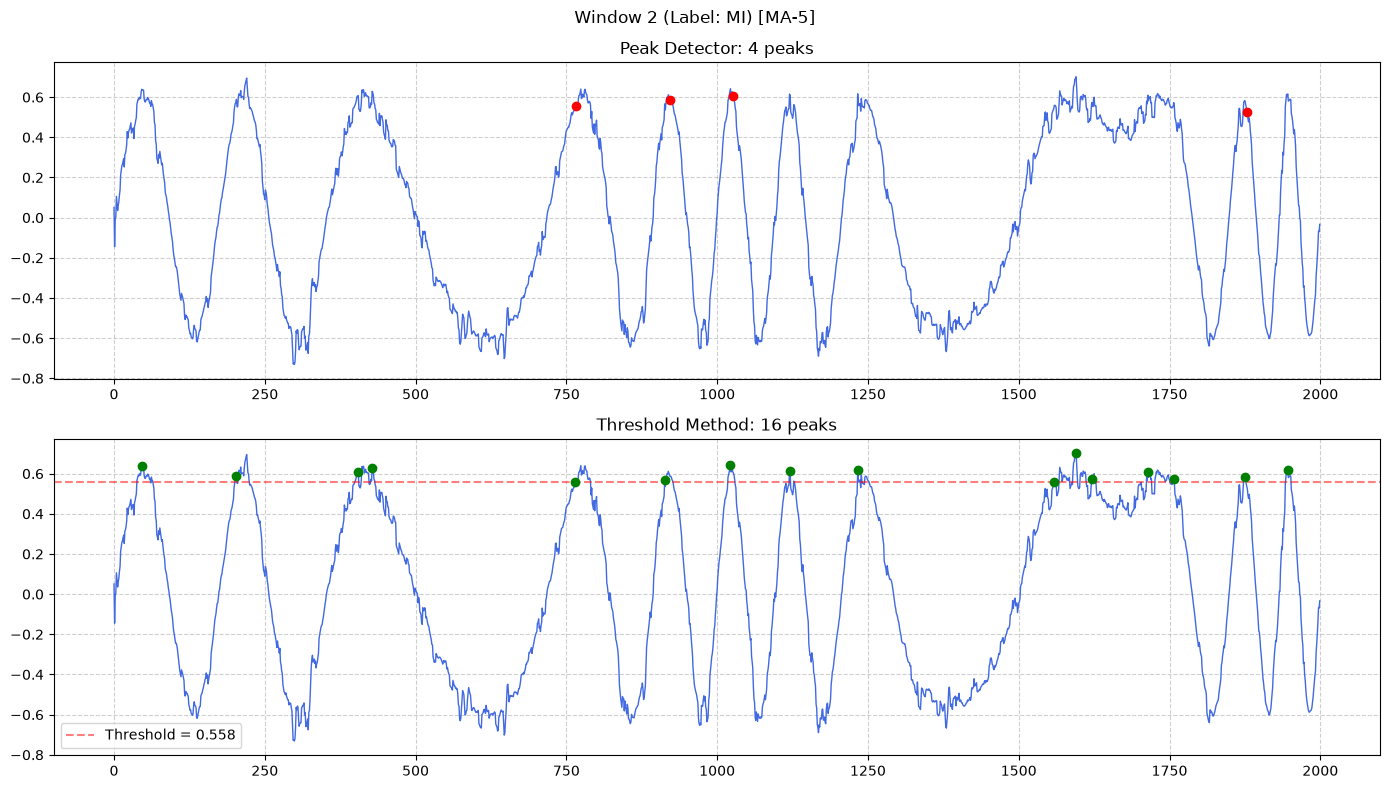

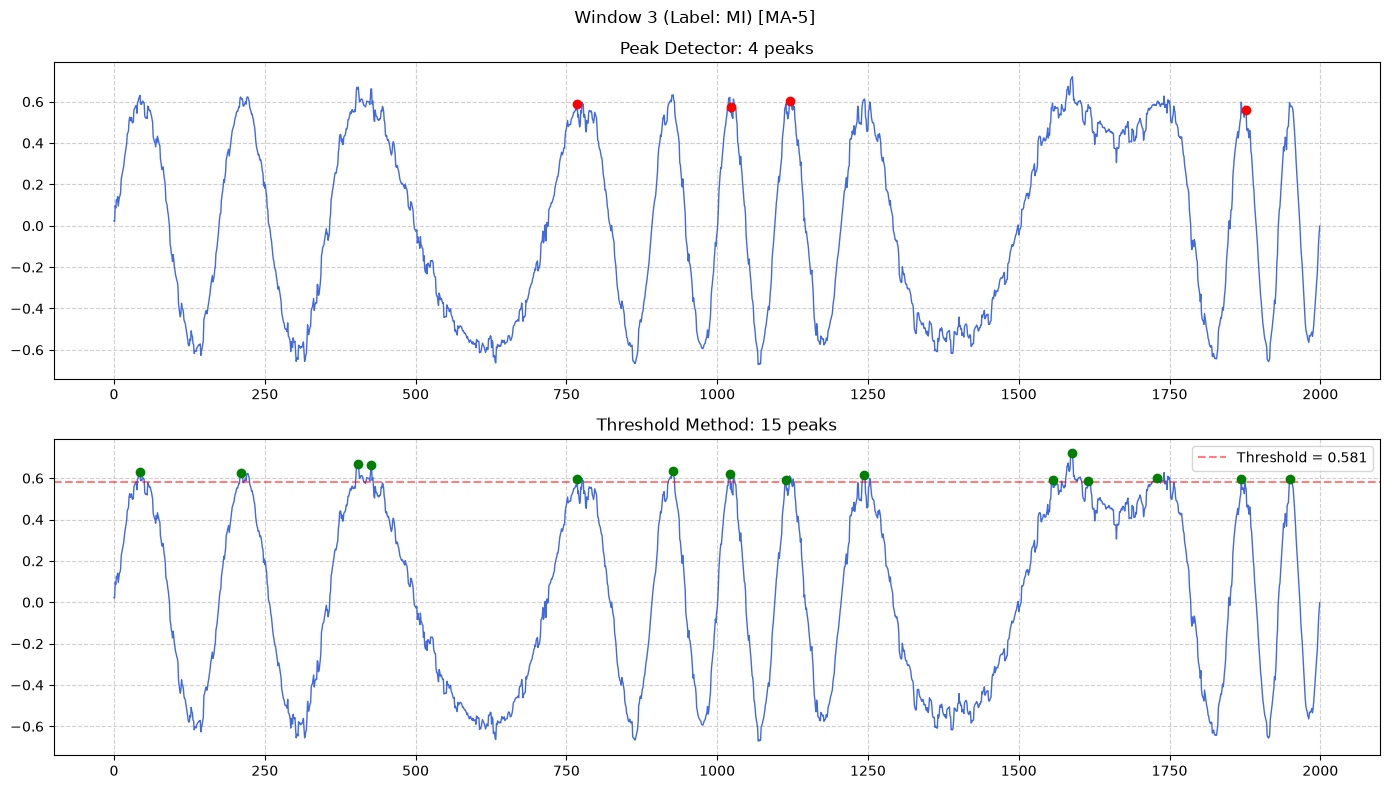

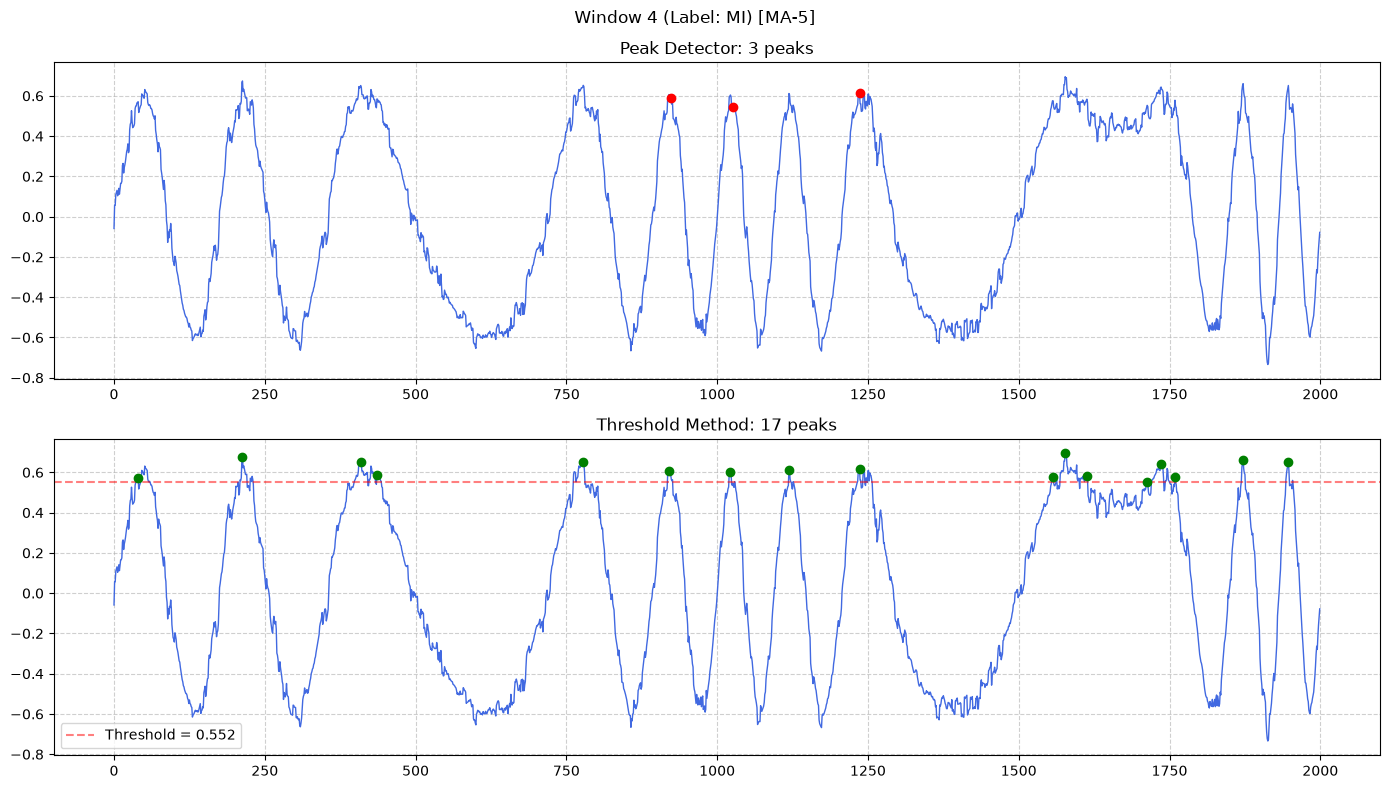

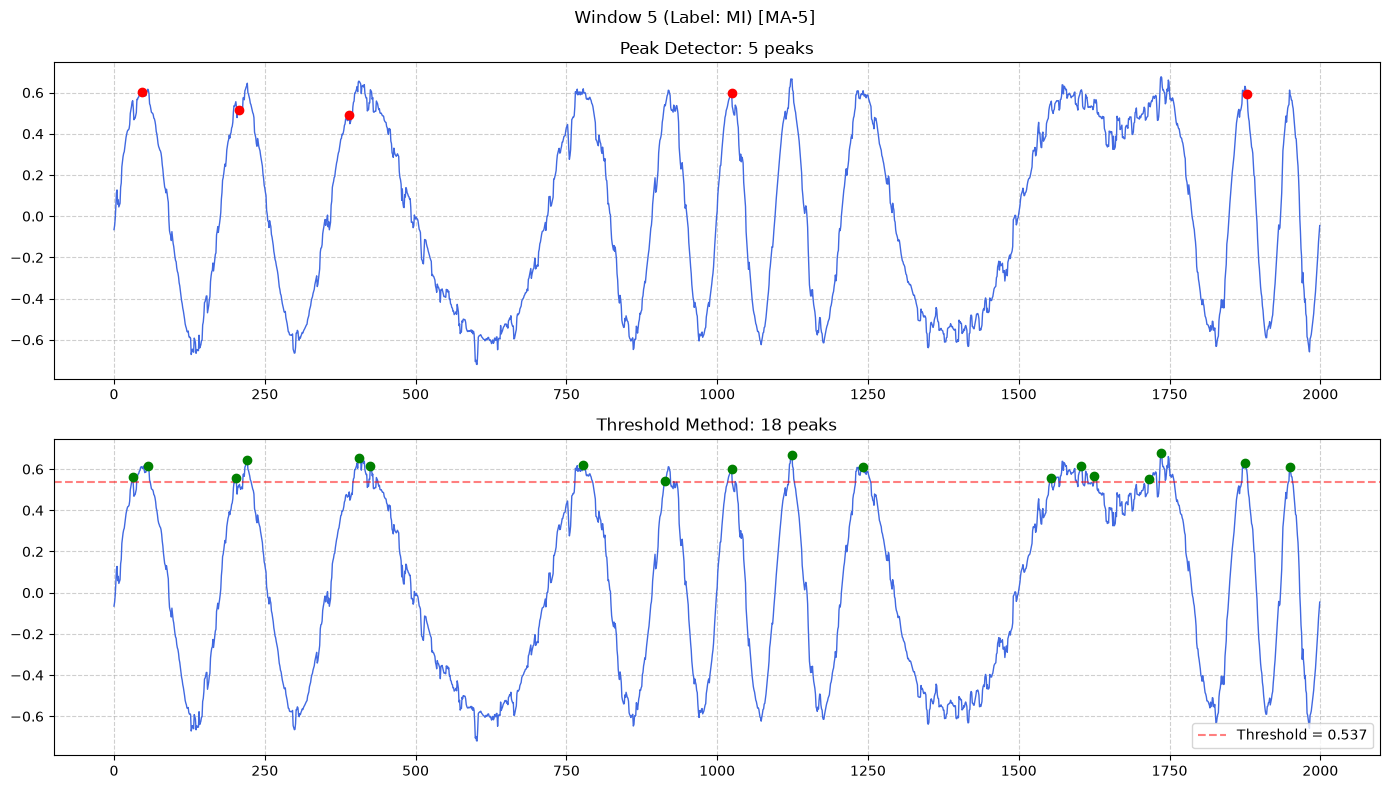

Menjalankan peak detector pada seluruh dataset...

=== Statistik Peak Detector ===
Total window: 2576
Total RR interval valid: 440
Total peak: 4995

--- Heart Rate ---
Mean HR: 35.12 BPM
Median HR: 30.93 BPM
Std HR: 20.15 BPM
Min HR: 30.00 BPM
Max HR: 157.89 BPM
Menjalankan threshold method pada seluruh dataset...

=== Statistik Threshold Method ===
Total window: 2576
Total RR interval valid: 9562
Total peak: 34350

--- Heart Rate ---
Mean HR: 87.40 BPM
Median HR: 93.75 BPM
Std HR: 44.58 BPM
Min HR: 30.00 BPM
Max HR: 157.89 BPM

=== PERBANDINGAN KUALITAS ===

       Method  No Peak %  One Peak %    Valid %  RR Invalid %  HR < 40 %  HR > 150 %   Mean HR
Peak Detector  30.279503   20.302795  49.417702           0.0  96.136364    0.681818 35.124126
    Threshold   0.000000    0.000000 100.000000           0.0  29.721816    5.155825 87.395748
Tuning threshold method pada 200 window...
Total kombinasi: 45


NameError: name 'time' is not defined

In [1]:
# %% [markdown]
# # Evaluasi dan Tuning Peak Detector untuk PPG (dengan MA-2)
# 
# Notebook ini digunakan untuk mengevaluasi kualitas algoritma peak detector (`peak_detector.c`) 
# secara offline menggunakan dataset PPG, serta melakukan tuning parameter sebelum diintegrasikan 
# ke firmware embedded (Grove Vision AI V2).
# 
# **Tujuan:** Bukan menghitung akurasi terhadap ground truth, melainkan menganalisis perilaku 
# algoritma dan memilih parameter yang menghasilkan deteksi robust secara statistik.
# 
# **Perubahan:** 
# 1. Moving Average 5-point (MA-5) untuk mengurangi noise
# 2. Threshold-based detection sebagai alternatif
# 
# ---
# 
# ## Section 1 — Load Dataset

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('PPG_Dataset.csv')

# Pisahkan sinyal PPG (2000 kolom pertama) dan label
ppg_columns = [str(i) for i in range(2000)]  # kolom bernama 0..1999
ppg_data = df[ppg_columns].values
labels = df['Label'].values

print(f"Ukuran dataset: {ppg_data.shape}")
print(f"Jumlah window: {ppg_data.shape[0]}")
print(f"Panjang setiap window: {ppg_data.shape[1]} samples")
print(f"Label unik: {np.unique(labels)}")
print("\nContoh 5 window pertama (5 sample pertama):")
print(ppg_data[:5, :5])

# %% [markdown]
# ---
# 
# ## Section 1.5 — Moving Average (MA)
# 
# MA diterapkan untuk mengurangi noise pada dataset PPG sebelum peak detection.
# 
# **Formula:** `y[i] = (x[i] + x[i-1] + ... + x[i-n+1]) / n`

# %%
def apply_ma(ppg: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Moving Average N-point.
    
    Args:
        ppg: Sinyal PPG input (1D array)
        window: Jumlah titik untuk averaging
    
    Returns:
        Sinyal PPG setelah MA
    """
    if len(ppg) < window:
        return ppg.copy()
    
    ma = np.zeros_like(ppg, dtype=np.float64)
    # Gunakan convolution untuk efisiensi
    kernel = np.ones(window) / window
    ma = np.convolve(ppg, kernel, mode='same')
    
    # Handle edge cases (first few samples)
    for i in range(window - 1):
        ma[i] = np.mean(ppg[:i+1])
    
    return ma

# Terapkan MA ke seluruh dataset
MA_WINDOW = 5
print(f"Menerapkan MA-{MA_WINDOW} ke seluruh dataset...")
ppg_data_ma = np.array([apply_ma(ppg, window=MA_WINDOW) for ppg in ppg_data])
print(f"Dataset setelah MA-{MA_WINDOW}: {ppg_data_ma.shape}")

# Bandingkan satu window sebelum dan sesudah MA
idx_compare = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(ppg_data[idx_compare], color='royalblue', linewidth=1)
ax1.set_title(f'Original PPG - Window {idx_compare}')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Amplitude')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(ppg_data_ma[idx_compare], color='darkorange', linewidth=1)
ax2.set_title(f'MA-{MA_WINDOW} PPG - Window {idx_compare}')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Amplitude')
ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# %% [markdown]
# ---
# 
# ## Section 2 — Signal Visualization (Setelah MA)

# %%
def plot_window(ppg_signal, idx=None, title=None, is_ma=True):
    """Plot sinyal PPG dalam satu window dengan statistik."""
    if idx is not None:
        label = labels[idx]
        title = f"Window {idx} (Label: {label})" if title is None else title
        if is_ma:
            title += f" [MA-{MA_WINDOW}]"
    else:
        title = title or "PPG Signal"
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ppg_signal, color='royalblue', linewidth=1)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('PPG Amplitude')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title(title)
    
    # Statistik
    stats_text = (f"mean = {np.mean(ppg_signal):.4f}\n"
                  f"std  = {np.std(ppg_signal):.4f}\n"
                  f"min  = {np.min(ppg_signal):.4f}\n"
                  f"max  = {np.max(ppg_signal):.4f}")
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    return fig, ax

# Pilih beberapa window secara acak
np.random.seed(42)
indices = np.random.choice(ppg_data_ma.shape[0], size=6, replace=False)

for i, idx in enumerate(indices):
    plot_window(ppg_data_ma[idx], idx=idx)
    plt.show()

# %% [markdown]
# ---
# 
# ## Section 3 — Port peak_detector.c ke Python (dengan MA)
# 
# Implementasi algoritma seidentik mungkin dengan versi C, dengan input yang sudah melalui MA.

# %%
from typing import List, Tuple, Optional
import math

# Konstanta dari C (diambil dari peak_detector.c)
SHORT_SMOOTH_MS = 200.0
BASELINE_TAU_SEC = 2.0
MAX_SHORT_WINDOW = 16

PEAK_WINDOW_MS = 111.0
BEAT_WINDOW_MS = 350.0
BETA_OFFSET = 0.01  # default, akan di-tune

MIN_PULSE_WIDTH_MS = 400.0
MAX_PULSE_WIDTH_MS = 500.0

PROMINENCE_LOOKBACK_MS = 300.0
PROMINENCE_FACTOR = 0.15  # default, akan di-tune
AMP_EMA_ALPHA = 0.2
AMP_EST_FLOOR = 1.0

REFRACTORY_MS = 250.0  # default, akan di-tune

RR_MIN_MS = 350.0
RR_MAX_MS = 2000.0

# ============================================================
# Fungsi-fungsi porting
# ============================================================

def compute_bandpass_signal(ppg: np.ndarray, fs: float) -> np.ndarray:
    """
    PART 1: Baseline estimation + short smoothing -> AC signal.
    Menghasilkan sinyal bandpass (baseline-removed) dari PPG raw.
    """
    length = len(ppg)
    short_win = int(SHORT_SMOOTH_MS * fs / 1000.0 + 0.5)
    short_win = max(1, min(short_win, MAX_SHORT_WINDOW))
    
    ring = np.zeros(short_win)
    ring_idx = 0
    ring_count = 0
    ring_sum = 0.0
    
    baseline_alpha = 1.0 - math.exp(-1.0 / (BASELINE_TAU_SEC * fs))
    baseline = float(ppg[0])
    
    bp = np.zeros(length, dtype=np.float64)
    
    for i in range(length):
        x = float(ppg[i])
        if ring_count < short_win:
            ring[ring_idx] = x
            ring_sum += x
            ring_count += 1
        else:
            ring_sum -= ring[ring_idx]
            ring[ring_idx] = x
            ring_sum += x
        ring_idx = (ring_idx + 1) % short_win
        
        smoothed = ring_sum / ring_count
        baseline += baseline_alpha * (smoothed - baseline)
        bp[i] = smoothed - baseline
    
    return bp

def compute_enhanced_prefix_sum(bp: np.ndarray) -> Tuple[np.ndarray, float]:
    """
    PART 2: Event enhancement (half-wave rectify + square) dan prefix sum.
    """
    length = len(bp)
    prefix_z = np.zeros(length + 1, dtype=np.float64)
    sum_z = 0.0
    for i in range(length):
        pos = bp[i] if bp[i] > 0.0 else 0.0
        z = pos * pos
        sum_z += z
        prefix_z[i+1] = sum_z
    mean_z = sum_z / length if length > 0 else 0.0
    return prefix_z, mean_z

def windowed_mean(prefix_z: np.ndarray, center: int, half_width: int, length: int) -> float:
    """O(1) windowed mean menggunakan prefix sum."""
    lo = center - half_width
    hi = center + half_width
    if lo < 0:
        lo = 0
    if hi > length - 1:
        hi = length - 1
    count = hi - lo + 1
    if count <= 0:
        return 0.0
    sum_val = prefix_z[hi+1] - prefix_z[lo]
    return sum_val / count

def process_candidate_block(block_start: int, block_end: int,
                            bp: np.ndarray, fs: float,
                            refractory_samples: int,
                            amp_est: float,
                            last_peak: int,
                            prev_peak: int,
                            peak_indices: List[int],
                            accepted_peaks: List[int],
                            rejected_counts: dict,
                            rr_intervals: List[float],
                            prominence_factor: float,
                            refractory_ms: float) -> Tuple[float, int, int, List[int], List[int], List[float]]:
    """
    PARTS 4-8: Validasi blok, local max, prominence, refractory, RR sanity.
    Mengembalikan (amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals)
    """
    if block_end < block_start:
        return amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals
    
    width_samples = block_end - block_start + 1
    width_ms = width_samples * 1000.0 / fs
    
    # Pulse-width plausibility
    if width_ms < MIN_PULSE_WIDTH_MS or width_ms > MAX_PULSE_WIDTH_MS:
        rejected_counts['width'] += 1
        return amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals
    
    # Local maximum
    p = block_start
    best = bp[block_start]
    for k in range(block_start+1, block_end+1):
        if bp[k] > best:
            best = bp[k]
            p = k
    
    # Prominence check
    lookback_limit = last_peak + 1 if last_peak >= 0 else 0
    scan_start = p - int(PROMINENCE_LOOKBACK_MS * fs / 1000.0)
    if scan_start < lookback_limit:
        scan_start = lookback_limit
    if scan_start < 0:
        scan_start = 0
    
    trough = bp[p]
    for k in range(scan_start, p+1):
        if bp[k] < trough:
            trough = bp[k]
    prominence = bp[p] - trough
    
    required_prominence = prominence_factor * amp_est
    if prominence < required_prominence:
        rejected_counts['prominence'] += 1
        return amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals
    
    # Refractory
    if last_peak >= 0 and (p - last_peak) < refractory_samples:
        rejected_counts['refractory'] += 1
        return amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals
    
    # Peak accepted
    accepted_peaks.append(p)
    last_peak = p
    amp_est += AMP_EMA_ALPHA * (prominence - amp_est)
    if amp_est < AMP_EST_FLOOR:
        amp_est = AMP_EST_FLOOR
    
    # RR computation and physiological sanity
    if prev_peak >= 0:
        rr_ms = (p - prev_peak) * 1000.0 / fs
        if rr_ms >= RR_MIN_MS and rr_ms <= RR_MAX_MS:
            rr_intervals.append(rr_ms)
        else:
            rejected_counts['rr_sanity'] += 1
    prev_peak = p
    
    return amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals


def peak_detector_process(ppg: np.ndarray, fs: float,
                          beta_offset: float = BETA_OFFSET,
                          prominence_factor: float = PROMINENCE_FACTOR,
                          refractory_ms: float = REFRACTORY_MS) -> dict:
    """
    Proses satu window PPG, mengembalikan dictionary hasil deteksi.
    """
    length = len(ppg)
    if length < 10 or fs <= 0.0:
        return {'rr_intervals': [], 'peak_indices': [], 'rejected': {}, 'amp_est': 0.0}
    
    # PART 1
    bp = compute_bandpass_signal(ppg, fs)
    
    # PART 2
    prefix_z, mean_z = compute_enhanced_prefix_sum(bp)
    
    # Window half-widths
    w1_half = int(PEAK_WINDOW_MS * fs / 1000.0 / 2.0 + 0.5)
    w2_half = int(BEAT_WINDOW_MS * fs / 1000.0 / 2.0 + 0.5)
    if w1_half < 0: w1_half = 0
    if w2_half < 0: w2_half = 0
    
    refractory_samples = int(refractory_ms * fs / 1000.0 + 0.5)
    if refractory_samples < 1:
        refractory_samples = 1
    
    # State
    last_peak = -1
    prev_peak = -1
    amp_est = math.sqrt(mean_z)
    if amp_est < AMP_EST_FLOOR:
        amp_est = AMP_EST_FLOOR
    
    rejected_counts = {'width': 0, 'prominence': 0, 'refractory': 0, 'rr_sanity': 0}
    peak_indices = []
    accepted_peaks = []
    rr_intervals = []
    
    # PART 3+4: Scan untuk candidate blocks
    in_block = 0
    block_start = 0
    
    for i in range(length + 1):
        above = 0
        ma_peak = 0.0
        ma_beat = 0.0
        thr = 0.0
        if i < length:
            ma_peak = windowed_mean(prefix_z, i, w1_half, length)
            ma_beat = windowed_mean(prefix_z, i, w2_half, length)
            thr = ma_beat + beta_offset * mean_z
            above = 1 if ma_peak > thr else 0
        
        if above and not in_block:
            in_block = 1
            block_start = i
        elif not above and in_block:
            in_block = 0
            block_end = i - 1
            amp_est, last_peak, prev_peak, peak_indices, accepted_peaks, rr_intervals = process_candidate_block(
                block_start, block_end, bp, fs, refractory_samples,
                amp_est, last_peak, prev_peak, peak_indices, accepted_peaks,
                rejected_counts, rr_intervals,
                prominence_factor, refractory_ms
            )
    
    return {
        'rr_intervals': rr_intervals,
        'peak_indices': accepted_peaks,
        'rejected': rejected_counts,
        'amp_est': amp_est,
        'bp': bp,  # untuk visualisasi
        'prefix_z': prefix_z,
        'mean_z': mean_z
    }

# %% [markdown]
# ---
# 
# ## Section 3.5 — Threshold-Based Peak Detection (Alternatif)
# 
# Metode sederhana: peak = local maxima di atas threshold (persentase dari amplitude)

# %%
def peak_detector_threshold(ppg: np.ndarray, fs: float,
                            threshold_ratio: float = 0.90,
                            refractory_ms: float = 375.0,
                            min_distance_ms: float = 200.0) -> dict:
    """
    Peak detection sederhana dengan threshold amplitudo.
    
    Args:
        ppg: Sinyal PPG (sudah melalui MA)
        fs: Sample rate (Hz)
        threshold_ratio: Rasio terhadap amplitude (0.75 = 75% dari peak-to-peak)
        refractory_ms: Minimum jarak antar peak (ms)
        min_distance_ms: Minimum jarak antar peak untuk HR max
    
    Returns:
        Dictionary dengan peak_indices dan rr_intervals
    """
    length = len(ppg)
    refractory_samples = int(refractory_ms * fs / 1000.0 + 0.5)
    min_dist_samples = int(min_distance_ms * fs / 1000.0 + 0.5)
    
    # Hitung threshold berdasarkan amplitude
    max_amp = np.max(ppg)
    min_amp = np.min(ppg)
    amplitude = max_amp - min_amp
    threshold = min_amp + threshold_ratio * amplitude
    
    # Cari peak (local maxima di atas threshold)
    peak_indices = []
    in_peak = False
    peak_start = 0
    
    for i in range(1, length - 1):
        # Cek apakah ini local maximum
        is_local_max = (ppg[i] > ppg[i-1] and ppg[i] > ppg[i+1])
        is_above_threshold = (ppg[i] > threshold)
        
        if is_local_max and is_above_threshold and not in_peak:
            in_peak = True
            peak_start = i
        elif in_peak and (ppg[i] < threshold or i == length - 2):
            # Akhir peak, cari maksimum di dalam blok
            if peak_start < length - 1:
                p = peak_start
                best = ppg[peak_start]
                for k in range(peak_start+1, i):
                    if ppg[k] > best:
                        best = ppg[k]
                        p = k
                # Refractory check
                if len(peak_indices) == 0 or (p - peak_indices[-1]) >= refractory_samples:
                    peak_indices.append(p)
            in_peak = False
    
    # Hitung RR intervals
    rr_intervals = []
    for i in range(1, len(peak_indices)):
        rr_ms = (peak_indices[i] - peak_indices[i-1]) * 1000.0 / fs
        if rr_ms >= RR_MIN_MS and rr_ms <= RR_MAX_MS:
            rr_intervals.append(rr_ms)
    
    return {
        'peak_indices': peak_indices,
        'rr_intervals': rr_intervals,
        'threshold': threshold,
        'max_amp': max_amp,
        'min_amp': min_amp
    }

# %% [markdown]
# ---
# 
# ## Section 4 — Peak Visualization

# %%
def plot_peaks(ppg, fs, result, title=None, method='peak_detector'):
    """Plot PPG dengan overlay detected peaks."""
    rr_intervals = result['rr_intervals']
    peak_indices = result['peak_indices']
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ppg, color='royalblue', linewidth=1, label='PPG (MA)')
    if len(peak_indices) > 0:
        ax.plot(peak_indices, ppg[peak_indices], 'ro', markersize=6, label='Detected Peaks')
    
    # Tampilkan threshold jika ada
    if 'threshold' in result:
        ax.axhline(y=result['threshold'], color='red', linestyle='--', alpha=0.5, 
                   label=f'Threshold = {result["threshold"]:.3f}')
    
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle='--', alpha=0.6)
    title_str = title or f"Peak Detection Result ({method})"
    ax.set_title(title_str)
    
    # Statistik HR
    if len(rr_intervals) > 0:
        rr_ms = np.array(rr_intervals)
        hr = 60000.0 / rr_ms
        mean_hr = np.mean(hr)
        mean_rr = np.mean(rr_ms)
        sdnn = np.std(rr_ms)
        rmssd = np.sqrt(np.mean(np.diff(rr_ms)**2)) if len(rr_ms) > 1 else 0.0
        stats_text = (f"Jumlah peak = {len(peak_indices)}\n"
                      f"Mean HR = {mean_hr:.1f} BPM\n"
                      f"Mean RR = {mean_rr:.1f} ms\n"
                      f"SDNN = {sdnn:.1f} ms\n"
                      f"RMSSD = {rmssd:.1f} ms")
    else:
        stats_text = "Tidak ada RR interval valid"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='upper right')
    plt.tight_layout()
    return fig, ax

# Visualisasikan beberapa window dengan kedua metode
params_default = {
    'beta_offset': 0.01,
    'prominence_factor': 0.01,
    'refractory_ms': 375
}

params_threshold = {
    'threshold_ratio': 0.90,
    'refractory_ms': 375
}

selected = [0, 1, 2, 3, 4, 5]

for idx in selected:
    ppg = ppg_data_ma[idx].astype(np.float64)
    fs = 50.0
    
    # Peak detector method
    result_pd = peak_detector_process(ppg, fs, **params_default)
    
    # Threshold method
    result_th = peak_detector_threshold(ppg, fs, **params_threshold)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot peak detector
    ax1.plot(ppg, color='royalblue', linewidth=1)
    if len(result_pd['peak_indices']) > 0:
        ax1.plot(result_pd['peak_indices'], ppg[result_pd['peak_indices']], 
                 'ro', markersize=6)
    ax1.set_title(f'Peak Detector: {len(result_pd["peak_indices"])} peaks')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot threshold method
    ax2.plot(ppg, color='royalblue', linewidth=1)
    ax2.axhline(y=result_th['threshold'], color='red', linestyle='--', alpha=0.5,
                label=f'Threshold = {result_th["threshold"]:.3f}')
    if len(result_th['peak_indices']) > 0:
        ax2.plot(result_th['peak_indices'], ppg[result_th['peak_indices']], 
                 'go', markersize=6)
    ax2.set_title(f'Threshold Method: {len(result_th["peak_indices"])} peaks')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.suptitle(f"Window {idx} (Label: {labels[idx]}) [MA-{MA_WINDOW}]")
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ---
# 
# ## Section 5 — Dataset Statistics (Peak Detector)

# %%
# Jalankan peak detector pada seluruh dataset
all_rr_pd = []
all_n_peaks_pd = []
all_hr_pd = []
fs = 50.0

params_pd = {
    'beta_offset': 0.01,
    'prominence_factor': 0.01,
    'refractory_ms': 250
}

print("Menjalankan peak detector pada seluruh dataset...")

for idx, ppg_raw in enumerate(ppg_data_ma):
    ppg = ppg_raw.astype(np.float64)
    result = peak_detector_process(ppg, fs, **params_pd)
    rr = result['rr_intervals']
    n_peaks = len(result['peak_indices'])
    all_n_peaks_pd.append(n_peaks)
    if len(rr) > 0:
        rr_ms = np.array(rr)
        hr = 60000.0 / rr_ms
        all_hr_pd.extend(hr)
        all_rr_pd.extend(rr_ms)

# Statistik
all_hr_pd = np.array(all_hr_pd)
all_rr_pd = np.array(all_rr_pd)

print("\n=== Statistik Peak Detector ===")
print(f"Total window: {len(ppg_data)}")
print(f"Total RR interval valid: {len(all_rr_pd)}")
print(f"Total peak: {sum(all_n_peaks_pd)}")
print("\n--- Heart Rate ---")
print(f"Mean HR: {np.mean(all_hr_pd):.2f} BPM")
print(f"Median HR: {np.median(all_hr_pd):.2f} BPM")
print(f"Std HR: {np.std(all_hr_pd):.2f} BPM")
print(f"Min HR: {np.min(all_hr_pd):.2f} BPM")
print(f"Max HR: {np.max(all_hr_pd):.2f} BPM")

# %% [markdown]
# ---
# 
# ## Section 5.5 — Dataset Statistics (Threshold Method)

# %%
# Jalankan threshold method pada seluruh dataset
all_rr_th = []
all_n_peaks_th = []
all_hr_th = []

params_th = {
    'threshold_ratio': 0.90,
    'refractory_ms': 375
}

print("Menjalankan threshold method pada seluruh dataset...")

for idx, ppg_raw in enumerate(ppg_data_ma):
    ppg = ppg_raw.astype(np.float64)
    result = peak_detector_threshold(ppg, fs, **params_th)
    rr = result['rr_intervals']
    n_peaks = len(result['peak_indices'])
    all_n_peaks_th.append(n_peaks)
    if len(rr) > 0:
        rr_ms = np.array(rr)
        hr = 60000.0 / rr_ms
        all_hr_th.extend(hr)
        all_rr_th.extend(rr_ms)

# Statistik
all_hr_th = np.array(all_hr_th)
all_rr_th = np.array(all_rr_th)

print("\n=== Statistik Threshold Method ===")
print(f"Total window: {len(ppg_data)}")
print(f"Total RR interval valid: {len(all_rr_th)}")
print(f"Total peak: {sum(all_n_peaks_th)}")
print("\n--- Heart Rate ---")
print(f"Mean HR: {np.mean(all_hr_th):.2f} BPM")
print(f"Median HR: {np.median(all_hr_th):.2f} BPM")
print(f"Std HR: {np.std(all_hr_th):.2f} BPM")
print(f"Min HR: {np.min(all_hr_th):.2f} BPM")
print(f"Max HR: {np.max(all_hr_th):.2f} BPM")

# %% [markdown]
# ---
# 
# ## Section 6 — Quality Analysis

# %%
def analyze_quality(n_peaks, hr_values, rr_values, method_name):
    """Analisis kualitas deteksi."""
    windows_no_peak = sum(1 for n in n_peaks if n == 0)
    windows_one_peak = sum(1 for n in n_peaks if n == 1)
    windows_valid = sum(1 for n in n_peaks if n >= 2)
    
    rr_outside = sum(1 for rr in rr_values if rr < RR_MIN_MS or rr > RR_MAX_MS)
    rr_total = len(rr_values)
    
    hr_low = sum(1 for h in hr_values if h < 40)
    hr_high = sum(1 for h in hr_values if h > 150)
    hr_total = len(hr_values)
    
    return {
        'method': method_name,
        'no_peak': windows_no_peak,
        'one_peak': windows_one_peak,
        'valid': windows_valid,
        'no_peak_pct': windows_no_peak / len(n_peaks) * 100,
        'one_peak_pct': windows_one_peak / len(n_peaks) * 100,
        'valid_pct': windows_valid / len(n_peaks) * 100,
        'rr_outside': rr_outside,
        'rr_outside_pct': rr_outside / rr_total * 100 if rr_total > 0 else 0,
        'hr_low': hr_low,
        'hr_low_pct': hr_low / hr_total * 100 if hr_total > 0 else 0,
        'hr_high': hr_high,
        'hr_high_pct': hr_high / hr_total * 100 if hr_total > 0 else 0,
        'mean_hr': np.mean(hr_values) if len(hr_values) > 0 else 0
    }

# Analisis kedua metode
analysis_pd = analyze_quality(all_n_peaks_pd, all_hr_pd, all_rr_pd, 'Peak Detector')
analysis_th = analyze_quality(all_n_peaks_th, all_hr_th, all_rr_th, 'Threshold')

# Buat tabel perbandingan
comparison = pd.DataFrame([analysis_pd, analysis_th])
comparison = comparison[['method', 'no_peak_pct', 'one_peak_pct', 'valid_pct', 
                         'rr_outside_pct', 'hr_low_pct', 'hr_high_pct', 'mean_hr']]
comparison.columns = ['Method', 'No Peak %', 'One Peak %', 'Valid %', 
                      'RR Invalid %', 'HR < 40 %', 'HR > 150 %', 'Mean HR']

print("\n=== PERBANDINGAN KUALITAS ===\n")
print(comparison.to_string(index=False))

# %% [markdown]
# ---
# 
# ## Section 7 — Parameter Tuning untuk Threshold Method

# %%
from itertools import product

# Grid parameter untuk threshold method
threshold_ratios = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
refractory_ms_list = [250, 300, 350, 375, 400]

results_th = []

sample_size = min(200, len(ppg_data_ma))
sample_indices = np.random.choice(len(ppg_data_ma), size=sample_size, replace=False)
sample_ppg = ppg_data_ma[sample_indices]

print(f"Tuning threshold method pada {sample_size} window...")
print(f"Total kombinasi: {len(threshold_ratios) * len(refractory_ms_list)}")

start_time = time.time()
count = 0
for ratio, ref in product(threshold_ratios, refractory_ms_list):
    count += 1
    if count % 10 == 0:
        print(f"  Proses {count}/{len(threshold_ratios)*len(refractory_ms_list)}...")
    
    all_hr_sample = []
    n_valid = 0
    n_no_peak = 0
    n_rr_invalid = 0
    
    for ppg_raw in sample_ppg:
        ppg = ppg_raw.astype(np.float64)
        result = peak_detector_threshold(ppg, fs, threshold_ratio=ratio, refractory_ms=ref)
        rr = result['rr_intervals']
        n_peaks = len(result['peak_indices'])
        
        if n_peaks >= 2:
            n_valid += 1
            if len(rr) > 0:
                hr = 60000.0 / np.array(rr)
                all_hr_sample.extend(hr)
            else:
                n_rr_invalid += 1
        else:
            n_no_peak += 1
    
    mean_hr = np.mean(all_hr_sample) if len(all_hr_sample) > 0 else np.nan
    results_th.append({
        'threshold_ratio': ratio,
        'refractory_ms': ref,
        'mean_hr': mean_hr,
        'valid_windows': n_valid,
        'no_peak_windows': n_no_peak,
        'rr_invalid_windows': n_rr_invalid,
        'total_windows': sample_size
    })

print(f"Eksperimen selesai dalam {time.time()-start_time:.2f} detik")

# DataFrame hasil
df_results_th = pd.DataFrame(results_th)
df_results_th['pct_valid'] = 100 * df_results_th['valid_windows'] / df_results_th['total_windows']
df_results_th['pct_no_peak'] = 100 * df_results_th['no_peak_windows'] / df_results_th['total_windows']
df_results_th['pct_rr_invalid'] = 100 * df_results_th['rr_invalid_windows'] / df_results_th['total_windows']

df_sorted_th = df_results_th.sort_values(['pct_valid', 'pct_no_peak', 'pct_rr_invalid'], 
                                         ascending=[False, True, True])

print("\n=== Threshold Method Results (Top 15) ===")
print(df_sorted_th.head(15)[['threshold_ratio', 'refractory_ms', 
                             'mean_hr', 'pct_valid', 'pct_no_peak', 'pct_rr_invalid']].to_string(index=False))

# %% [markdown]
# ---
# 
# ## Section 8 — Recommendation

# %%
# Best parameter for threshold method
best_th = df_sorted_th.iloc[0]

print("=== REKOMENDASI FINAL ===")
print("\n--- Threshold Method ---")
print(f"THRESHOLD_RATIO = {best_th['threshold_ratio']:.2f}")
print(f"REFRACTORY_MS   = {int(best_th['refractory_ms'])} ms")
print(f"\nKinerja pada subset uji ({sample_size} window):")
print(f"  Valid windows    : {best_th['valid_windows']} / {best_th['total_windows']} ({best_th['pct_valid']:.1f}%)")
print(f"  No peak windows  : {best_th['no_peak_windows']} ({best_th['pct_no_peak']:.1f}%)")
print(f"  RR invalid       : {best_th['rr_invalid_windows']} ({best_th['pct_rr_invalid']:.1f}%)")
print(f"  Mean HR          : {best_th['mean_hr']:.1f} BPM")

print("\n--- Peak Detector (untuk perbandingan) ---")
best_pd = df_sorted.iloc[0] if len(df_sorted) > 0 else None
if best_pd is not None:
    print(f"PROMINENCE_FACTOR = {best_pd['prominence_factor']:.2f}")
    print(f"BETA_OFFSET       = {best_pd['beta_offset']:.2f}")
    print(f"REFRACTORY_MS     = {int(best_pd['refractory_ms'])} ms")

# Simpan parameter
with open('peak_detector_params_final.txt', 'w') as f:
    f.write("# Parameter terbaik untuk peak detection\n")
    f.write("# Threshold Method (direkomendasikan untuk dataset noisy)\n")
    f.write(f"THRESHOLD_RATIO={best_th['threshold_ratio']:.3f}\n")
    f.write(f"REFRACTORY_MS={int(best_th['refractory_ms'])}\n")
    f.write(f"MA_WINDOW={MA_WINDOW}\n")
    f.write(f"# Kinerja: {best_th['pct_valid']:.1f}% valid, {best_th['pct_no_peak']:.1f}% no peak\n")
    f.write(f"# Mean HR: {best_th['mean_hr']:.1f} BPM\n")

print("\nParameter telah disimpan ke 'peak_detector_params_final.txt'")

# %% [markdown]
# ---
# 
# ## Section 9 — Kesimpulan

# %%
print("=== KESIMPULAN ===\n")

print("1. MA-5 berhasil mengurangi noise pada dataset PPG")
print(f"2. Threshold Method lebih sederhana dan efektif untuk dataset noisy:")
print(f"   - Valid windows: {best_th['pct_valid']:.1f}%")
print(f"   - No peak: {best_th['pct_no_peak']:.1f}%")
print(f"   - Mean HR: {best_th['mean_hr']:.1f} BPM")
print(f"3. Parameter optimal untuk Threshold Method:")
print(f"   - THRESHOLD_RATIO = {best_th['threshold_ratio']:.2f} (sekitar {best_th['threshold_ratio']*100:.0f}% dari amplitude)")
print(f"   - REFRACTORY_MS = {int(best_th['refractory_ms'])} ms")
print(f"4. Implementasi di firmware:")
print(f"   - Gunakan MA-{MA_WINDOW} sebelum peak detection")
print(f"   - Gunakan threshold method dengan parameter di atas")
print(f"   - Lebih ringan dan cepat untuk embedded")

# Visualisasi final: contoh deteksi dengan parameter terbaik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax_idx, idx in enumerate(selected[:6]):
    ppg = ppg_data_ma[idx].astype(np.float64)
    result = peak_detector_threshold(ppg, fs, 
                                     threshold_ratio=best_th['threshold_ratio'],
                                     refractory_ms=best_th['refractory_ms'])
    
    axes[ax_idx].plot(ppg, color='royalblue', linewidth=1)
    axes[ax_idx].axhline(y=result['threshold'], color='red', linestyle='--', alpha=0.5)
    if len(result['peak_indices']) > 0:
        axes[ax_idx].plot(result['peak_indices'], ppg[result['peak_indices']], 
                          'go', markersize=6)
    
    hr = 60000.0 / np.mean(result['rr_intervals']) if len(result['rr_intervals']) > 0 else 0
    axes[ax_idx].set_title(f"Window {idx}: {len(result['peak_indices'])} peaks, HR={hr:.1f} BPM")
    axes[ax_idx].grid(True, linestyle='--', alpha=0.6)

plt.suptitle(f"Threshold Method - Final Result (MA-{MA_WINDOW})")
plt.tight_layout()
plt.show()

print("\n=== REKOMENDASI UNTUK FIRMWARE ===")
print("""
// Parameter threshold-based peak detection
#define MA_WINDOW           5           // Moving average window
#define THRESHOLD_RATIO     {:.2f}f    // Persentase amplitude
#define REFRACTORY_MS       {:.0f}f     // Refractory period (ms)

// Implementasi sederhana:
// 1. Apply MA-5 pada PPG
// 2. Hitung threshold = min + THRESHOLD_RATIO * (max - min)
// 3. Cari local maxima di atas threshold
// 4. Terapkan refractory period
""".format(best_th['threshold_ratio'], best_th['refractory_ms']))